# FigHeatCool — net energy budget vs depth across two wind families

Comparing the **marginally-unbound** `dilute_redd` winds (top row, panels a–d) with the **photon-tired**
$f=0.94$ ($\Gamma_0=1.21$) winds (bottom row, panels e–h), at $\dot M$ = 2.5/5/10/20 $M_\odot/\mathrm{yr}$.

**2×4 ridgelines: net energy budget vs electron-scattering depth.** Vertical axis is $\tau_{\rm es}$
(scattering surface $\tau_{\rm es}{=}1$ near top, base below). At each depth a filled envelope shows the **local**
net budget per process, $(\mathrm{heat}-\mathrm{cool})/\mathrm{cool}_{\rm tot}$: **net coolants (sinks)
are negative, left of the spine; net heaters (sources) are positive, right**, width capped at 1 (the
optically-thin limit where a channel's cooling is fully net). A **wide envelope = gas far from local balance**
(active reprocessing); a **collapse to the spine = detailed balance / thermalized**. Channels: bf/recomb (red),
free-free (orange), lines (blue). Black horizontal markers: **scattering surface $\tau_{\rm es}{=}1$**
(solid), **Lyman break** (dotted), **Balmer break** (dashed). Exact sim columns (`heat_phot`/`cool_rr`
already contain the on-the-spot recombination cycle, so it cancels).

The picture: **marginally-unbound winds stay out of local balance at every depth** (fat envelopes; bf the
net heater absorbing the trapped Balmer continuum, ff+lines the net coolants). **Photon-tired winds
($\sim$10× denser at fixed $\dot M$) thermalize deep down** — their envelopes pinch to a thread below
$\tau_{\rm es}\sim$ few, in near-perfect detailed balance.

In [1]:
import os, glob
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FixedLocator, FixedFormatter
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

# ================= config: edit here to point at your data / output =================
# (self-contained per notebook for now; lift this block into a shared repro_paths.py
#  once the final matrix_pow + custom-band reruns exist and dirs are unified.)
DATA_ROOT = os.environ.get("SIROCCO_REPRO_DATA", "/scratch/gpfs/nk6352/sirocco_runs")
FIG_DIR   = os.path.abspath("../figures")           # where this notebook writes its PDF/PNG
RUN_SET   = os.environ.get("SIROCCO_REPRO_RUNSET", "repro")   # "legacy" (paper freeze) | "repro" (repro/ reruns)
# NOTE: repro/ runs = matrix_pow + Photon_sampling=wide. Photon-tired family = ptf_*
#   (f=0.94 tiring fraction, Gamma_0=1.2128 Owocki+2017 winds), superseding the legacy
#   g1.38 pt_* family; all four ptf runs completed & health-checked 2026-08-13.
#   ptf m10/m20 unconverged cells lie beyond the H recombination front (t_e collapse in
#   decoupled neutral gas; converged inside), so SPECTRA come from the *_trunc_speconly
#   extraction reruns where noted, while wind-structure tables read the parent dirs.
#   Verified 2026-08-11 against the legacy matrix_bb runs: mu_* AND pt_* are healthy
#   (the earlier matrix_pow pt_* under-ionization is gone; e.g. pt_m5 mid-wind h1~6e-4,
#   matching legacy ~5e-4). Integrated 2000-10000 A flux matches legacy to <~8% for all
#   runs except pt_m20 (0.42x the legacy g1.38_hires run; m20 is the known poorly-converged
#   case, and the gallery takes its m20 spectra from the *_trunc_speconly reruns).
RUN_DIRS_LEGACY  = {"MU_m2.5": "1d_m2.5_dilute_redd_hires", "MU_m5":  "1d_m5_dilute_redd",
             "MU_m10":  "1d_m10_dilute_redd",        "MU_m20": "1d_m20_dilute_redd",
             "PT_m2.5": "photon_tired_winds/m2.5_g1.38_hires", "PT_m5":  "photon_tired_winds/m5_g1.38_hires",
             "PT_m10":  "photon_tired_winds/m10_g1.38_hires",  "PT_m20": "photon_tired_winds/m20_g1.38_hires"}
RUN_DIRS_REPRO = {"MU_m2.5": "repro/mu_m2.5", "MU_m5": "repro/mu_m5",
                   "MU_m10": "repro/mu_m10", "MU_m20": "repro/mu_m20",
                   "PT_m2.5": "repro/ptf_m2.5", "PT_m5": "repro/ptf_m5",
                   "PT_m10": "repro/ptf_m10", "PT_m20": "repro/ptf_m20"}
RUN_DIRS  = {"legacy": RUN_DIRS_LEGACY, "repro": RUN_DIRS_REPRO}[RUN_SET]
def run_path(k): return os.path.join(DATA_ROOT, RUN_DIRS[k])
os.makedirs(FIG_DIR, exist_ok=True)

# ---- manuscript style ----
plt.rcParams.update({
    'figure.dpi': 140, 'savefig.dpi': 300, 'savefig.bbox': 'tight',
    'font.family': 'serif', 'mathtext.fontset': 'dejavuserif',
    'font.size': 9, 'axes.titlesize': 10, 'axes.labelsize': 10,
    'axes.linewidth': 0.8, 'lines.linewidth': 1.0,
    'xtick.direction': 'in', 'ytick.direction': 'in',
    'xtick.top': True, 'ytick.right': True,
    'xtick.minor.visible': True, 'ytick.minor.visible': True,
})
# ====================================================================================

# ---- physical constants (cgs) ----
KB=1.3807e-16; MP=1.6726e-24; XH=0.71; SIGT=6.652e-25
NU_BALMER=8.2249e14; NU_LYMAN=4*NU_BALMER
MDOTS=['m2.5','m5','m10','m20']
MDNUM={'m2.5':2.5,'m5':5,'m10':10,'m20':20}
FAMILIES={
 'MU':dict(label='marginally unbound',color='tab:orange',
   runs={'m2.5':'MU_m2.5','m5':'MU_m5','m10':'MU_m10','m20':'MU_m20'}),
 'PT':dict(label=r'photon-tired',color='tab:blue',
   runs={'m2.5':'PT_m2.5','m5':'PT_m5','m10':'PT_m10','m20':'PT_m20'})}
LS={'m2.5':'-','m5':'--','m10':'-.','m20':(0,(1,1))}
PROC=[('bound-free','bf','#FC5942'),('free-free','ff','#FC8E41'),('lines','ln','#428AFC')]

def load_heat(rd): h=pd.read_csv(f'{rd}/outflow.heat.txt',sep=r'\s+'); return h[h['inwind']==0].reset_index(drop=True)
def load_jnu(rd):
    x=pd.read_csv(sorted(glob.glob(f'{rd}/outflow.xspec.all*.txt'))[0],sep=r'\s+')
    cols=[c for c in x.columns if c!='Freq.' and c.startswith('F')]; return x['Freq.'].values,x[cols].values
def tau_of_r(r,ne):
    n=len(r); dr=np.empty(n); dr[:-1]=np.diff(r); dr[-1]=dr[-2]; return np.cumsum((ne*SIGT*dr)[::-1])[::-1]
def edge_break_radius(freq,jnu,r,nu_edge,jt=np.e):
    ib=np.argmin(np.abs(freq-nu_edge*0.97)); ia=np.argmin(np.abs(freq-nu_edge*1.03))
    jump=jnu[ib,:]/np.maximum(jnu[ia,:],1e-99); d=np.log(np.maximum(jump,1e-99))-np.log(jt)
    s=np.where(np.diff(np.sign(d))!=0)[0]
    return (np.interp(0.0,[d[s[0]],d[s[0]+1]],[r[s[0]],r[s[0]+1]]) if len(s) else np.nan)

# --- ridgeline data: per-cell LOCAL net by process vs tau_es ---
#   nets = (heat_chan - cool_chan)/cool_tot  -> net cooling NEGATIVE (left), net heating POSITIVE (right).
#   cvs = converged mask (unconverged drawn faded). tauLy / tauBa = tau_es at the Lyman / Balmer break.
def ridge_data(rd):
    h=load_heat(rd); r=h['r'].values; ne=h['ne'].values; ct=h['cool_tot'].values
    tau=tau_of_r(r,ne); cv=h['converge'].values==0
    nabs={'bf':(h['heat_phot']-h['cool_rr']).values,'ff':(h['heat_ff']-h['lum_ff']).values,
          'ln':(h['heat_line']-h['lum_lines']).values}                    # erg/s, net heating
    keep=(tau>=0.6)&(ct>0); o=np.argsort(tau[keep])
    ts=tau[keep][o]; cts=ct[keep][o]; cvs=cv[keep][o]
    nets={k:nabs[k][keep][o]/cts for k in nabs}
    freq,jnu=load_jnu(rd)
    rLy=edge_break_radius(freq,jnu,r,NU_LYMAN);  tauLy=float(np.interp(rLy,r,tau))
    rBa=edge_break_radius(freq,jnu,r,NU_BALMER); tauBa=float(np.interp(rBa,r,tau))
    return ts,nets,tauLy,tauBa,cvs

RIDGE={fk:{md:ridge_data(run_path(fv['runs'][md])) for md in MDOTS} for fk,fv in FAMILIES.items()}
print("tau_es at the breaks  (Ly / Ba):")
for fk in FAMILIES:
    print(f"  {fk}: "+"  ".join(f"{md}=Ly{RIDGE[fk][md][2]:.0f}/Ba{RIDGE[fk][md][3]:.0f}" for md in MDOTS))

tau_es at the breaks  (Ly / Ba):
  MU: m2.5=Ly3/Banan  m5=Ly11/Banan  m10=Ly23/Ba3  m20=Ly41/Ba6
  PT: m2.5=Ly57/Banan  m5=Lynan/Ba2  m10=Ly0/Ba5  m20=Ly35/Ba5


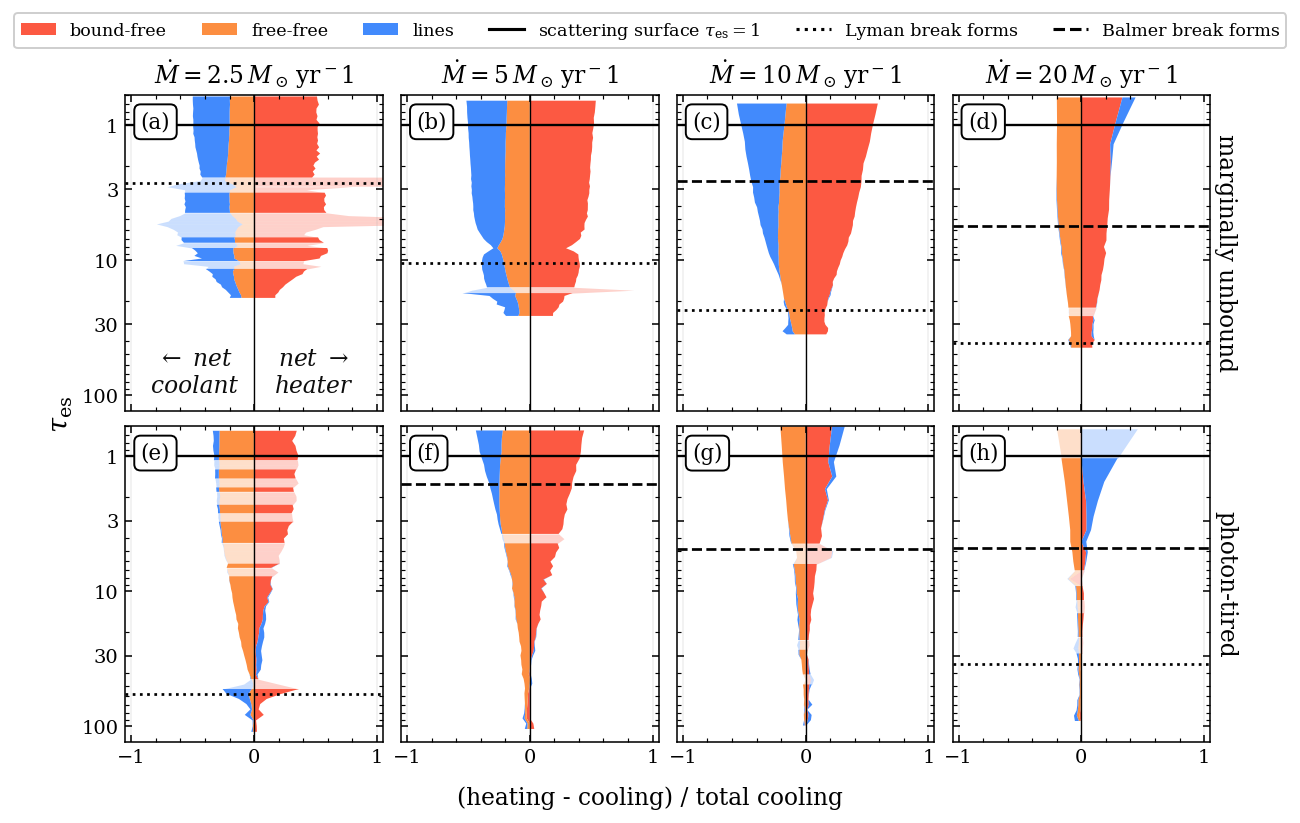

In [2]:
fig=plt.figure(figsize=(10,6))
rgs=fig.add_gridspec(2,4,hspace=0.05,wspace=0.07)

LETTERS='abcdefgh'
axref=None
for ri,fk in enumerate(['MU','PT']):
    for ci,md in enumerate(MDOTS):
        ax=fig.add_subplot(rgs[ri,ci],sharey=axref,sharex=axref); axref=axref or ax
        ts,nets,tauLy,tauBa,cvs=RIDGE[fk][md]
        r0=np.zeros_like(ts); l0=np.zeros_like(ts); unc=~cvs
        for nm,key,col in PROC:
            v=np.nan_to_num(nets[key]); rc=np.maximum(v,0); lc=np.maximum(-v,0); Rhi=r0+rc; Lhi=-(l0+lc)
            ax.fill_betweenx(ts,r0,Rhi,where=cvs,color=col,lw=0)          # solid: contiguous converged runs (no seams)
            ax.fill_betweenx(ts,-l0,Lhi,where=cvs,color=col,lw=0)
            for i in range(len(ts)-1):                                    # faded patches over unconverged cells
                if unc[i] or unc[i+1]:
                    sl=slice(i,i+2)
                    ax.fill_betweenx(ts[sl],r0[sl],Rhi[sl],color=col,alpha=0.28,lw=0)
                    ax.fill_betweenx(ts[sl],-l0[sl],Lhi[sl],color=col,alpha=0.28,lw=0)
            r0=Rhi; l0=l0+lc
        ax.axvline(0,color='k',lw=0.7)
        ax.axhline(1.0,color='k',ls='-',lw=1.2)                          # scattering surface tau_es=1
        ax.axhline(tauLy,color='k',ls=':',lw=1.4)                       # Lyman break
        ax.axhline(tauBa,color='k',ls='--',lw=1.4)                      # Balmer break
        ax.set_yscale('log'); ax.set_ylim(130,0.6); ax.set_xlim(-1.05,1.05)
        ax.yaxis.set_major_locator(FixedLocator([1,3,10,30,100]))
        ax.yaxis.set_major_formatter(FixedFormatter(['1','3','10','30','100']))
        ax.text(0.06,0.95,f'({LETTERS[ri*4+ci]})',transform=ax.transAxes,fontsize=11,va='top',ha='left',
                bbox=dict(facecolor='white',boxstyle='round'))
        if ri==0 and ci==0:                                              # heater/coolant guide in panel (a)
            ax.text(0.27,0.20,r'$\leftarrow$ net'+'\ncoolant',transform=ax.transAxes,ha='center',va='top',
                    fontsize=12,style='italic',color='0.05')
            ax.text(0.73,0.20,r'net $\rightarrow$'+'\nheater',transform=ax.transAxes,ha='center',va='top',
                    fontsize=12,style='italic',color='0.05')
        if ri==0:
            ax.set_title(rf'$\dot{{M}} = {MDNUM[md]:g}\,M_\odot\,\mathrm{{yr}}^{-1}$',fontsize=12)
            plt.setp(ax.get_xticklabels(),visible=False)                 # top row shares x with bottom row
        if ci==0: pass
        else: plt.setp(ax.get_yticklabels(),visible=False)
        if ci==3:                                                        # family label to the right, black
            ax.text(1.06,0.5,FAMILIES[fk]['label'],transform=ax.transAxes,rotation=270,
                    va='center',ha='center',color='k',fontsize=12)
        ax.tick_params(labelsize=10); ax.grid(axis='x',alpha=0.2)
H=([Patch(fc=c,label=nm) for nm,_,c in PROC]
   +[Line2D([0],[0],color='k',ls='-',lw=1.6,label=r'scattering surface $\tau_{\rm es}{=}1$'),
     Line2D([0],[0],color='k',ls=':',lw=1.6,label='Lyman break forms'),
     Line2D([0],[0],color='k',ls='--',lw=1.6,label='Balmer break forms')])
fig.legend(handles=H,loc='lower center',bbox_to_anchor=(0.5,0.925),ncol=6,fontsize=9,framealpha=0.95)

fig.supxlabel(r'(heating - cooling) / total cooling',fontsize=12,y=0.03)
fig.supylabel(r'$\tau_{\rm es}$',fontsize=14,x=0.07)

fig.savefig(os.path.join(FIG_DIR,'FigHeatCool.pdf'))
fig.savefig(os.path.join(FIG_DIR,'FigHeatCool.png'),dpi=300)
plt.show()